# Category Intelligence — Retail Product Performance EDA

**Calibo AI Academy · Phase 1 · Mini Use Case 01 · Path 2 — KLU Batch**

**Team:** [12]

| Member | Role | Sections owned |
|---|---|---|
| Geetha | Data Analyst | CBIM Problem Canvas · Step 6.1 Load & Inspect · Step 6.2 Category Revenue Trend |
| Javeed | Product Insights Analyst | Step 6.3 Top & Bottom Products |
| Ashok  | Discount & Pattern Analyst | Step 6.4 Discount Effectiveness · Step 6.5 Day-of-Week & Monthly Patterns |
| Vikas  | Business Synthesis Analyst | Step 6.6 Category Manager Briefing |

*Note on roles: the assignment brief defines roles for teams of two or three. This team has four
members, so the split above is our own internal allocation of the same six required steps — it is not
an official structure prescribed by the brief.*

**Dataset:** `MUC01_Retail_Sales_Dataset.csv` — six months of transaction data (Jan–Jun 2026) from a
12-store regional retail chain in Andhra Pradesh.

**Purpose:** equip the Category Manager with a data-backed position for the quarterly supplier review.

---

# CBIM Problem Canvas

*Completed by the full team before any code was written. Owned by Geetha (Data Analyst).*

| Canvas element | Our answer |
|---|---|
| **Situation (S)** | A regional retail chain runs 12 stores across six Andhra Pradesh cities — Vijayawada, Guntur, Rajahmundry, Tirupati, Nellore and Kakinada — selling across five categories: Electronics, Apparel, Grocery, Home & Kitchen and Personal Care. Six months of transaction-level sales (Jan–Jun 2026) are available, and the Category Manager has a quarterly supplier review next week at which each category's suppliers will argue for continued shelf space and promotional investment. |
| **Complication (C)** | Suppliers will arrive with their own version of the story. The Category Manager currently has no consolidated, transaction-level view of which categories are growing or declining, which products inside each category are carrying the category, or whether the discounts the chain is funding are buying any incremental volume. Without that, shelf-space and promotional-spend decisions will be made on assertion rather than evidence. |
| **Question (Q)** | Over Jan–Jun 2026, which categories are growing and which are declining, which products are driving or dragging each category, and is the discount programme generating incremental volume? The decision this enables: where to move shelf space and promotional spend, and which category to put under commercial challenge in the supplier review. |
| **SSOT** | `MUC01_Retail_Sales_Dataset.csv` — the transaction-level sales extract for all 12 stores, Jan–Jun 2026. Every figure quoted in the supplier review must be reproducible from this file; no external or supplier-supplied numbers are used. |
| **Success definition** | The Category Manager walks into the review able to name one category she is backing and one she is challenging, quote the revenue figure behind each claim, state what the discount programme has and has not delivered, and be explicit about the one piece of data she still needs. A good output is a position, not a pack of charts. |
| **Primary stakeholder** | The Category Manager. She needs to leave with a defensible ranking of the five categories, a specific product-level challenge, a clear line on discounts, and a named data request to close out before the final shelf-space decision. |

---

# Step 6.1 — Load and Inspect the Data

**Owner: Geetha — Data Analyst**

Before any analysis we establish what the single source of truth actually contains, and whether it is
fit to be quoted in a supplier meeting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ---- House chart style: one palette and one labelling convention for the whole notebook ----
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 110,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# Fixed category colours so every chart in the notebook reads the same way
CATEGORY_COLOURS = {
    "Electronics":    "#1f4e79",
    "Apparel":        "#c0504d",
    "Grocery":        "#4f8a3d",
    "Home & Kitchen": "#e08a1e",
    "Personal Care":  "#7b5ea7",
}
ACCENT = "#1f4e79"

def inr(x, decimals=2):
    """Format a rupee amount in business-readable units (Cr / L / plain)."""
    if abs(x) >= 1e7:
        return f"\u20b9{x/1e7:,.{decimals}f} Cr"
    if abs(x) >= 1e5:
        return f"\u20b9{x/1e5:,.{decimals}f} L"
    return f"\u20b9{x:,.0f}"

def rupee_axis(ax, scale=1e6, suffix=" Mn", decimals=1):
    """Apply rupee formatting to the y-axis of a chart."""
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"\u20b9{v/scale:,.{decimals}f}{suffix}")
    )

print("Libraries loaded. Chart style set for the whole notebook.")

Libraries loaded. Chart style set for the whole notebook.


In [2]:
df = pd.read_csv("MUC01_Retail_Sales_Dataset.csv")

print("Rows, Columns:", df.shape)
print("\nColumns:", list(df.columns))
df.head()

Rows, Columns: (107836, 10)

Columns: ['transaction_id', 'date', 'store_id', 'store_city', 'category', 'product_name', 'units_sold', 'unit_price', 'revenue', 'discount_pct']


,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN000001,2026-01-01,S01,Vijayawada,Electronics,Smart TV,2,3075.46,5843.37,5
1,TXN000002,2026-01-01,S01,Vijayawada,Electronics,Laptop,1,11598.06,11598.06,0
2,TXN000003,2026-01-01,S01,Vijayawada,Electronics,Tablet,3,5738.37,15493.60,10
3,TXN000004,2026-01-01,S01,Vijayawada,Electronics,Smart TV,3,3281.28,9351.65,5
4,TXN000005,2026-01-01,S01,Vijayawada,Apparel,Jeans,1,1917.14,1917.14,0


In [3]:
df.tail(3)

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
107833,TXN107834,2026-06-30,S12,Kakinada,Personal Care,Shampoo,2,808.72,1536.57,5
107834,TXN107835,2026-06-30,S12,Kakinada,Personal Care,Face Wash,5,237.13,1185.65,0
107835,TXN107836,2026-06-30,S12,Kakinada,Personal Care,Face Wash,1,921.75,783.49,15


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 107836 entries, 0 to 107835
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   transaction_id  107836 non-null  str    
 1   date            107836 non-null  str    
 2   store_id        107836 non-null  str    
 3   store_city      107836 non-null  str    
 4   category        107836 non-null  str    
 5   product_name    107836 non-null  str    
 6   units_sold      107836 non-null  int64  
 7   unit_price      107836 non-null  float64
 8   revenue         107836 non-null  float64
 9   discount_pct    107836 non-null  int64  
dtypes: float64(2), int64(2), str(6)
memory usage: 8.2 MB


In [5]:
quality = pd.DataFrame({
    "Data type": df.dtypes.astype(str),
    "Null values": df.isnull().sum(),
    "Null %": (df.isnull().mean() * 100).round(2),
    "Unique values": df.nunique(),
})
print("DATA TYPE AND NULL-VALUE AUDIT")
quality

DATA TYPE AND NULL-VALUE AUDIT


,Data type,Null values,Null %,Unique values
transaction_id,str,0,0.0,107836
date,str,0,0.0,181
store_id,str,0,0.0,12
store_city,str,0,0.0,6
category,str,0,0.0,5
product_name,str,0,0.0,25
units_sold,int64,0,0.0,12
unit_price,float64,0,0.0,76071
revenue,float64,0,0.0,91184
discount_pct,int64,0,0.0,5


In [6]:
print("DUPLICATE CHECK")
print("Fully duplicated rows            :", df.duplicated().sum())
print("Duplicated transaction_id values :", df["transaction_id"].duplicated().sum())

print("\nVALUE-RANGE SANITY CHECK")
print("Negative or zero revenue rows    :", int((df["revenue"] <= 0).sum()))
print("Negative or zero units_sold rows :", int((df["units_sold"] <= 0).sum()))
print("discount_pct outside 0-100       :", int(((df["discount_pct"] < 0) | (df["discount_pct"] > 100)).sum()))

DUPLICATE CHECK
Fully duplicated rows            : 0
Duplicated transaction_id values : 0

VALUE-RANGE SANITY CHECK
Negative or zero revenue rows    : 0
Negative or zero units_sold rows : 0
discount_pct outside 0-100       : 0


In [7]:
df.describe().round(2)

,units_sold,unit_price,revenue,discount_pct
count,107836.00,107836.00,107836.00,107836.00
mean,2.58,1778.10,4263.92,7.23
std,1.47,5053.63,14243.24,6.73
min,1.00,50.02,40.04,0.00
25%,1.00,274.83,467.77,0.00
50%,2.00,488.45,1034.62,5.00
75%,3.00,1039.52,2473.34,10.00
max,13.00,44990.14,355090.88,20.00


In [8]:
print("Unique categories :", df["category"].nunique())
print("Categories        :", sorted(df["category"].unique()))
print("\nUnique products   :", df["product_name"].nunique())
print("Products per category:")
print(df.groupby("category")["product_name"].nunique().to_string())

print("\nUnique stores     :", df["store_id"].nunique())
print("Store cities      :", sorted(df["store_city"].unique()))
print("\nDate range        :", df["date"].min(), "to", df["date"].max())
print("Distinct dates    :", df["date"].nunique())
print("Discount values present (%):", sorted(df["discount_pct"].unique()))
print("\nTotal chain revenue over the period:", inr(df["revenue"].sum()))

Unique categories : 5
Categories        : ['Apparel', 'Electronics', 'Grocery', 'Home & Kitchen', 'Personal Care']

Unique products   : 25
Products per category:
category
Apparel           5
Electronics       5
Grocery           5
Home & Kitchen    5
Personal Care     5

Unique stores     : 12
Store cities      : ['Guntur', 'Kakinada', 'Nellore', 'Rajahmundry', 'Tirupati', 'Vijayawada']

Date range        : 2026-01-01 to 2026-06-30
Distinct dates    : 181
Discount values present (%): [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20)]

Total chain revenue over the period: ₹45.98 Cr


In [9]:
cat_mix = (df.groupby("category")
             .agg(Transactions=("transaction_id", "count"),
                  Units=("units_sold", "sum"),
                  Revenue=("revenue", "sum"))
             .sort_values("Revenue", ascending=False))
cat_mix["Revenue share %"] = (cat_mix["Revenue"] / cat_mix["Revenue"].sum() * 100).round(1)
cat_mix["Avg revenue / transaction"] = (cat_mix["Revenue"] / cat_mix["Transactions"]).round(0)
print("CATEGORY MIX — Jan to Jun 2026")
cat_mix

CATEGORY MIX — Jan to Jun 2026


,Transactions,Units,Revenue,Revenue share %,Avg revenue / transaction
category,,,,,
Electronics,4015,10372,2.265277e+08,49.3,56420.0
Home & Kitchen,8388,21658,8.184572e+07,17.8,9757.0
Apparel,15301,39456,6.947959e+07,15.1,4541.0
Grocery,54185,140326,4.230258e+07,9.2,781.0
Personal Care,25947,66781,3.964856e+07,8.6,1528.0


### What the data says — [Geetha]

**What the dataset contains.** 107,836 transactions across 10 columns, covering every day from
2026-01-01 to 2026-06-30 (181 distinct dates) for 12 stores (S01–S12) in six Andhra Pradesh cities.
Five categories carry **25 products — exactly five products per category**, which is a well-balanced
assortment and means any revenue gap between categories is a demand or pricing story, not an
assortment-size story. Total chain revenue over the six months is **₹45.98 Cr**.

**Data quality: clean, and safe to quote in the supplier review.** There are **no null values in any
column**, **no fully duplicated rows**, and **no duplicated `transaction_id` values**. No transaction
has zero or negative revenue or units, and every `discount_pct` sits inside a sensible range. No
cleaning or imputation was required — an important point, because every number in this notebook is
going to be quoted back to suppliers.

**Observation 1 from `describe()` — the chain sells a few very expensive things and a great many
cheap ones.** Median revenue per transaction is **₹1,034.62** but the mean is **₹4,263.92**, and the
maximum is **₹355,090.88**. Mean unit price (₹1,778.10) similarly sits far above the median
(₹488.45). That heavy right skew means chain revenue is disproportionately exposed to a small number
of high-ticket transactions. For the business, this is a concentration risk: a modest fall in
big-ticket footfall moves the top line far more than anything happening in the everyday basket, so
averages alone will mislead the Category Manager and category-level trends must be read separately.

**Observation 2 — basket size is remarkably uniform, so revenue is driven by price and footfall, not
by basket building.** `units_sold` runs from 1 to 13 with a mean of **2.58** and a median of 2, and
the interquartile range is just 1 to 3. Customers buy roughly the same number of units regardless of
what they are buying. Any revenue movement the Category Manager sees is therefore almost entirely a
function of *which* products are being bought and *how many people* are buying — which is exactly why
the discount question in Step 6.4 matters: if discounts are not moving units, they are not moving
anything except realised price.

**Observation 3 — the category mix is highly concentrated.** Electronics alone is **49.3% of chain
revenue (₹22.65 Cr)** on only 4,015 transactions, while Grocery generates ₹4.23 Cr from 54,185
transactions. Electronics is the chain's revenue engine and its single biggest point of exposure —
which makes its trend line (Step 6.2) the most consequential chart in this analysis.

**One discrepancy with the assignment brief, flagged for transparency.** The brief describes
`discount_pct` as ranging from 0 to 30%. The actual file contains only **five discount levels: 0, 5,
10, 15 and 20%**. There are no transactions above 20%. We analyse the brackets that exist and report
the 25%+ bracket as empty rather than inventing observations for it (Step 6.4).

---

# Step 6.2 — Category Revenue Trend Over Time

**Owner: Mulla_Javeed — Data Analyst**

This is the chart the Category Manager will open the supplier review with: six months of revenue for
all five categories, on one pair of axes.

In [10]:
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M")
df["month_label"] = df["date"].dt.strftime("%b %Y")

monthly_category = (df.pivot_table(index="month", columns="category",
                                   values="revenue", aggfunc="sum")
                      .sort_index())

print("MONTHLY REVENUE BY CATEGORY (\u20b9 Crore)")
(monthly_category / 1e7).round(3)

MONTHLY REVENUE BY CATEGORY (₹ Crore)


category,Apparel,Electronics,Grocery,Home & Kitchen,Personal Care
month,,,,,
2026-01,1.005,4.569,0.731,1.513,0.659
2026-02,0.951,3.899,0.653,1.301,0.579
2026-03,1.154,4.085,0.713,1.436,0.681
2026-04,1.168,3.709,0.705,1.343,0.642
2026-05,1.322,3.423,0.723,1.358,0.730
2026-06,1.348,2.969,0.705,1.233,0.674


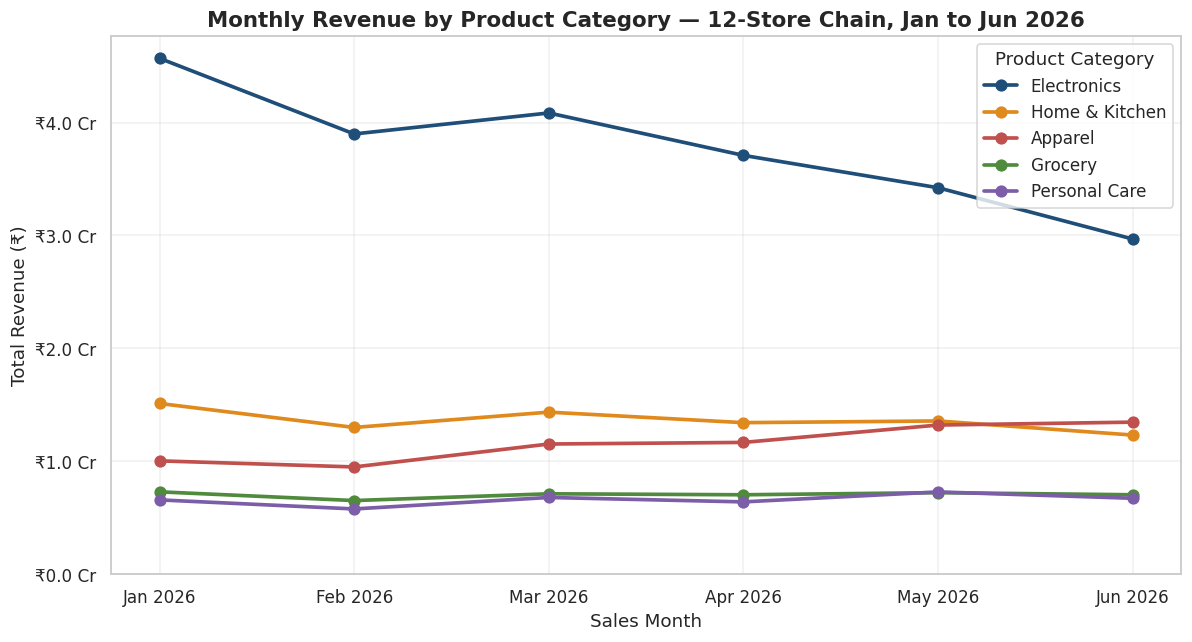

In [11]:
MONTH_ORDER = [p.strftime("%b %Y") for p in monthly_category.index]

fig, ax = plt.subplots()
for cat in cat_mix.index:                       # plotted largest category first
    ax.plot(MONTH_ORDER, monthly_category[cat].values,
            marker="o", linewidth=2.4, markersize=7,
            color=CATEGORY_COLOURS[cat], label=cat)

ax.set_title("Monthly Revenue by Product Category — 12-Store Chain, Jan to Jun 2026")
ax.set_xlabel("Sales Month")
ax.set_ylabel("Total Revenue (\u20b9)")
rupee_axis(ax, scale=1e7, suffix=" Cr", decimals=1)
ax.set_ylim(bottom=0)
ax.legend(title="Product Category", loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

In [12]:
# --- Overall change across the six months, calculated, not eyeballed ---
first_month, last_month = monthly_category.index[0], monthly_category.index[-1]

trend = pd.DataFrame({
    "Jan 2026 revenue": monthly_category.loc[first_month],
    "Jun 2026 revenue": monthly_category.loc[last_month],
})
trend["Change (\u20b9)"] = trend["Jun 2026 revenue"] - trend["Jan 2026 revenue"]
trend["Change %"] = (trend["Change (\u20b9)"] / trend["Jan 2026 revenue"] * 100).round(2)
trend = trend.sort_values("Change %")

print("CATEGORY-LEVEL CHANGE, JANUARY vs JUNE 2026")
trend.round(2)

CATEGORY-LEVEL CHANGE, JANUARY vs JUNE 2026


,Jan 2026 revenue,Jun 2026 revenue,Change (₹),Change %
category,,,,
Electronics,45686596.63,29686824.81,-15999771.82,-35.02
Home & Kitchen,15130871.54,12333283.07,-2797588.47,-18.49
Grocery,7307011.34,7047719.23,-259292.11,-3.55
Personal Care,6593734.81,6737354.12,143619.31,2.18
Apparel,10049916.78,13476952.88,3427036.10,34.10


In [13]:
# --- Month-over-month movement and consistency ---
mom = (monthly_category.pct_change() * 100).round(2)
print("MONTH-OVER-MONTH REVENUE CHANGE (%)")
print(mom.to_string())

consistency = pd.DataFrame({
    "Mean monthly revenue": monthly_category.mean(),
    "Std dev of monthly revenue": monthly_category.std(),
})
consistency["Coefficient of variation %"] = (
    consistency["Std dev of monthly revenue"] / consistency["Mean monthly revenue"] * 100).round(2)
consistency["Months of decline (of 5)"] = (mom < 0).sum()
consistency["Jan-Jun change %"] = trend["Change %"]
consistency = consistency.sort_values("Coefficient of variation %")

print("\nCONSISTENCY OF EACH CATEGORY (lower coefficient of variation = steadier)")
print(consistency.round(2).to_string())

print("\nSteepest decline   :", trend.index[0],
      f"({trend['Change %'].iloc[0]:+.2f}%, {inr(trend['Change (\u20b9)'].iloc[0])})")
print("Most consistent    :", consistency.index[0],
      f"(CV {consistency['Coefficient of variation %'].iloc[0]:.2f}%, "
      f"Jan-Jun {consistency['Jan-Jun change %'].iloc[0]:+.2f}%)")
print("Strongest growth   :", trend.index[-1],
      f"({trend['Change %'].iloc[-1]:+.2f}%, {inr(trend['Change (\u20b9)'].iloc[-1])})")

MONTH-OVER-MONTH REVENUE CHANGE (%)
category  Apparel  Electronics  Grocery  Home & Kitchen  Personal Care
month                                                                 
2026-01       NaN          NaN      NaN             NaN            NaN
2026-02     -5.36       -14.66   -10.57          -14.04         -12.15
2026-03     21.34         4.77     9.15           10.42          17.53
2026-04      1.22        -9.19    -1.20           -6.48          -5.73
2026-05     13.16        -7.72     2.63            1.12          13.73
2026-06      1.95       -13.26    -2.56           -9.19          -7.69

CONSISTENCY OF EACH CATEGORY (lower coefficient of variation = steadier)
                Mean monthly revenue  Std dev of monthly revenue  Coefficient of variation %  Months of decline (of 5)  Jan-Jun change %
category                                                                                                                                
Grocery                   7050430.13            

In [14]:
# --- Control for unequal month lengths (February has 28 days) before drawing conclusions ---
days_in_month = df.groupby("month")["date"].nunique()
avg_daily = monthly_category.div(days_in_month, axis=0)

print("TRADING DAYS PER MONTH")
print(days_in_month.to_string())

print("\nAVERAGE DAILY REVENUE BY CATEGORY (\u20b9 Lakh) - removes the February length effect")
print((avg_daily / 1e5).round(2).to_string())

daily_change = ((avg_daily.iloc[-1] - avg_daily.iloc[0]) / avg_daily.iloc[0] * 100).round(2)
print("\nJan-Jun change on an average-daily basis (%):")
print(daily_change.sort_values().to_string())

TRADING DAYS PER MONTH
month
2026-01    31
2026-02    28
2026-03    31
2026-04    30
2026-05    31
2026-06    30
Freq: M

AVERAGE DAILY REVENUE BY CATEGORY (₹ Lakh) - removes the February length effect
category  Apparel  Electronics  Grocery  Home & Kitchen  Personal Care
month                                                                 
2026-01      3.24        14.74     2.36            4.88           2.13
2026-02      3.40        13.92     2.33            4.65           2.07
2026-03      3.72        13.18     2.30            4.63           2.20
2026-04      3.89        12.36     2.35            4.48           2.14
2026-05      4.26        11.04     2.33            4.38           2.35
2026-06      4.49         9.90     2.35            4.11           2.25

Jan-Jun change on an average-daily basis (%):
category
Electronics      -32.85
Home & Kitchen   -15.77
Grocery           -0.33
Personal Care      5.58
Apparel           38.57


### What this means for the supplier review

**What happened.** Electronics fell from **₹4.57 Cr in January to ₹2.97 Cr in June — a 35.02% decline,
₹1.60 Cr of revenue gone** — and it is the only category that declined in four of its five
month-over-month steps. The decline is not a February calendar artefact: on an average-daily basis,
which removes February's shorter month, Electronics still falls **32.85%**. Over the same window
**Apparel grew 34.10% (₹1.00 Cr → ₹1.35 Cr, +₹34.27 L)**, rising in every month except February.
**Grocery is the most consistent performer** with a coefficient of variation of just **3.87%** across
the six months and an effectively flat Jan–Jun position (−3.55%); Personal Care was broadly stable at
+2.18%, and Home & Kitchen slipped 18.49%.

**Why it matters to the Category Manager.** Electronics is 49.3% of chain revenue, so its slide *is*
the chain's slide — total monthly revenue fell from ₹8.48 Cr in January to ₹6.93 Cr in June, a loss of
₹1.55 Cr. Electronics alone lost ₹1.60 Cr, meaning it lost *more* than the whole chain did and growth
elsewhere (principally Apparel) absorbed the difference. The supplier presenting Electronics will almost
certainly point to being the largest category by revenue. Size is not the question; direction is. A
supplier holding half the chain's revenue and losing a third of it in six months is asking the chain
to fund a declining asset, and the trend line is the evidence that reframes that conversation.

**What action this suggests.**
- **Electronics — challenge, do not cut blind.** Hold the shelf space pending the Step 6.3 product
  drill-down, but make continued promotional investment conditional on the supplier explaining the
  decline and committing to a recovery plan with a measurable June-exit run rate.
- **Apparel — back it.** It is the only category with sustained growth and it has absorbed a rising
  share of chain revenue without extra shelf space. It has the strongest evidence-based case for
  incremental space and promotional funding, taken from Electronics' promotional budget rather than
  from new spend.
- **Grocery — protect, do not promote.** Its value is stability and footfall, not growth. Promotional
  rupees spent here buy very little movement; treat it as the traffic base that supports the rest of
  the store.

---

# Step 6.3 — Top and Bottom Products by Category

**Owner: Javeed — Product Insights Analyst**

Category-level trends tell the Category Manager *where* the problem is. Product-level revenue tells
her *what* to put on the table in the meeting.

In [15]:
product_perf = (df.groupby(["category", "product_name"])
                  .agg(total_revenue=("revenue", "sum"),
                       units_sold=("units_sold", "sum"),
                       transactions=("transaction_id", "count"),
                       avg_unit_price=("unit_price", "mean"),
                       avg_discount_pct=("discount_pct", "mean"))
                  .reset_index())

product_perf["revenue_share_in_category_%"] = (
    product_perf["total_revenue"]
    / product_perf.groupby("category")["total_revenue"].transform("sum") * 100).round(2)

print("Products analysed:", len(product_perf), "across", product_perf["category"].nunique(), "categories")
product_perf.sort_values(["category", "total_revenue"], ascending=[True, False]).round(2).head(10)

Products analysed: 25 across 5 categories


,category,product_name,total_revenue,units_sold,transactions,avg_unit_price,avg_discount_pct,revenue_share_in_category_%
3,Apparel,Saree,14161864.63,7909,3078,1918.98,7.29,20.38
4,Apparel,T-Shirt,14099251.65,8028,3123,1893.89,7.23,20.29
1,Apparel,Jeans,13862749.46,7857,2985,1906.71,7.28,19.95
0,Apparel,Formal Shirt,13748976.91,7954,3082,1873.69,7.04,19.79
2,Apparel,Kurta,13606747.03,7708,3033,1902.15,7.09,19.58
5,Electronics,Headphones,47696053.99,2096,790,24043.63,7.04,21.06
6,Electronics,Laptop,46551078.39,2153,837,23421.77,7.54,20.55
7,Electronics,Mobile Phone,45654037.41,2077,796,23765.41,7.01,20.15
9,Electronics,Tablet,44744388.93,2069,820,23667.54,7.34,19.75
8,Electronics,Smart TV,41882166.21,1977,772,22514.20,6.92,18.49


In [16]:
# --- Consolidated top-2 / bottom-2 table for all five categories ---
rows = []
for cat in sorted(product_perf["category"].unique()):
    sub = product_perf[product_perf["category"] == cat].sort_values("total_revenue", ascending=False)
    for i, (_, r) in enumerate(sub.head(2).iterrows(), start=1):
        rows.append([cat, f"Top {i}", r["product_name"], r["total_revenue"], r["units_sold"]])
    bottom = sub.tail(2).sort_values("total_revenue")           # weakest first
    for i, (_, r) in enumerate(bottom.iterrows(), start=1):
        rows.append([cat, f"Bottom {i}", r["product_name"], r["total_revenue"], r["units_sold"]])

top_bottom = pd.DataFrame(rows, columns=["Category", "Rank", "Product",
                                         "Total Revenue (\u20b9)", "Units Sold"])
top_bottom["Total Revenue (\u20b9)"] = top_bottom["Total Revenue (\u20b9)"].round(2)

print("TOP 2 AND BOTTOM 2 PRODUCTS BY TOTAL REVENUE, BY CATEGORY (Jan-Jun 2026)")
top_bottom

TOP 2 AND BOTTOM 2 PRODUCTS BY TOTAL REVENUE, BY CATEGORY (Jan-Jun 2026)


,Category,Rank,Product,Total Revenue (₹),Units Sold
0,Apparel,Top 1,Saree,14161864.63,7909
1,Apparel,Top 2,T-Shirt,14099251.65,8028
2,Apparel,Bottom 1,Kurta,13606747.03,7708
3,Apparel,Bottom 2,Formal Shirt,13748976.91,7954
4,Electronics,Top 1,Headphones,47696053.99,2096
5,Electronics,Top 2,Laptop,46551078.39,2153
6,Electronics,Bottom 1,Smart TV,41882166.21,1977
7,Electronics,Bottom 2,Tablet,44744388.93,2069
8,Grocery,Top 1,Rice (5kg),8562171.86,28329
9,Grocery,Top 2,Dal (1kg),8488303.64,28026


In [17]:
# --- How far apart are the best and worst product inside each category? ---
spread = (product_perf.groupby("category")["total_revenue"]
          .agg(best="max", worst="min", category_total="sum"))
spread["Gap (\u20b9)"] = spread["best"] - spread["worst"]
spread["Worst as % of best"] = (spread["worst"] / spread["best"] * 100).round(1)
spread["Category total (\u20b9 Cr)"] = (spread["category_total"] / 1e7).round(2)

print("REVENUE SPREAD BETWEEN THE BEST AND WORST PRODUCT IN EACH CATEGORY")
print(spread[["Gap (\u20b9)", "Worst as % of best", "Category total (\u20b9 Cr)"]].round(2).to_string())

print("\nELECTRONICS - PRODUCT REVENUE BY MONTH (\u20b9 Lakh), the declining category from Step 6.2")
elec_monthly = (df[df["category"] == "Electronics"]
                .pivot_table(index="month", columns="product_name",
                             values="revenue", aggfunc="sum"))
print((elec_monthly / 1e5).round(1).to_string())

elec_change = ((elec_monthly.iloc[-1] - elec_monthly.iloc[0]) / elec_monthly.iloc[0] * 100).round(1)
print("\nElectronics Jan-Jun change by product (%):")
print(elec_change.sort_values().to_string())

elec_txn = df[df["category"] == "Electronics"].groupby("month").agg(
    transactions=("transaction_id", "count"),
    units=("units_sold", "sum"),
    avg_unit_price=("unit_price", "mean"))
print("\nElectronics transactions, units and average unit price by month:")
print(elec_txn.round(2).to_string())

REVENUE SPREAD BETWEEN THE BEST AND WORST PRODUCT IN EACH CATEGORY
                   Gap (₹)  Worst as % of best  Category total (₹ Cr)
category                                                             
Apparel          555117.60                96.1                   6.95
Electronics     5813887.78                87.8                  22.65
Grocery          184385.81                97.8                   4.23
Home & Kitchen  1077412.41                93.6                   8.18
Personal Care    574464.81                93.0                   3.96

ELECTRONICS - PRODUCT REVENUE BY MONTH (₹ Lakh), the declining category from Step 6.2
product_name  Headphones  Laptop  Mobile Phone  Smart TV  Tablet
month                                                           
2026-01             91.0    94.9          98.0      75.3    97.6
2026-02             79.7    79.5          78.6      65.6    86.4
2026-03             74.7    76.2          86.9      90.9    79.7
2026-04             87.2    71.

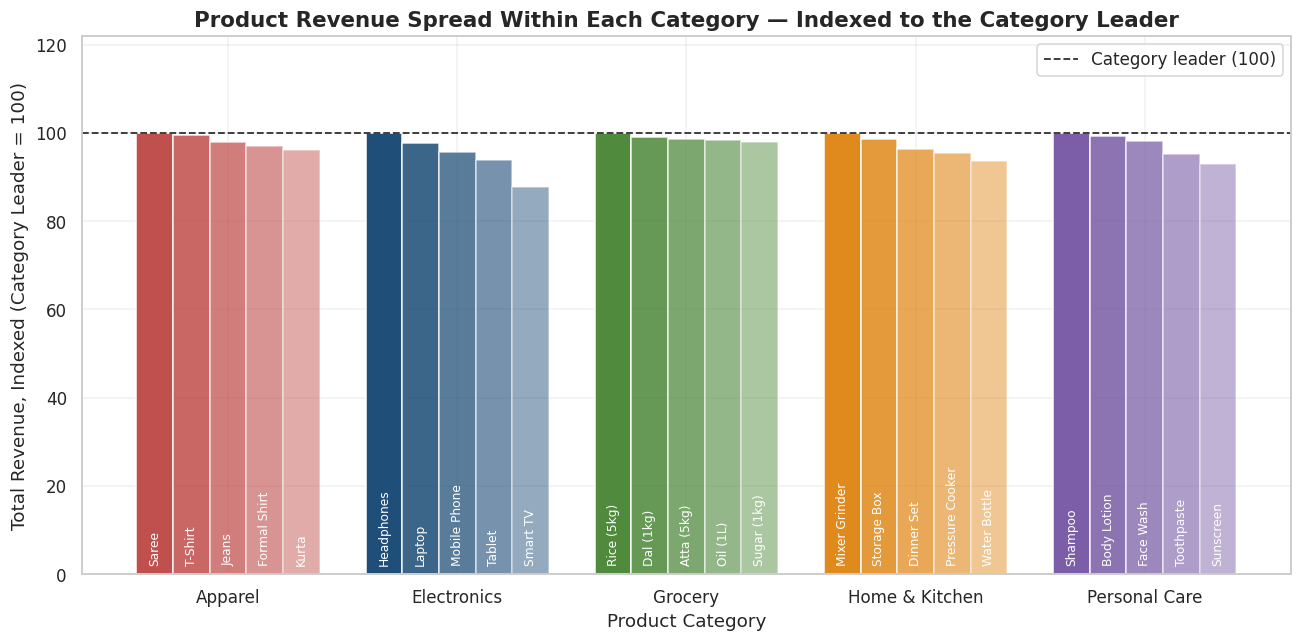

In [18]:
# Indexed against the strongest product in each category (100 = category leader), so the
# five categories can be compared on one axis despite very different revenue scales.
idx = product_perf.copy()
idx["index_vs_category_leader"] = (
    idx["total_revenue"] / idx.groupby("category")["total_revenue"].transform("max") * 100)

cats = sorted(idx["category"].unique())
fig, ax = plt.subplots(figsize=(12, 6))
width = 0.16
for k in range(5):                      # rank 1..5 within each category
    vals, labels = [], []
    for c in cats:
        sub = idx[idx["category"] == c].sort_values("total_revenue", ascending=False)
        vals.append(sub["index_vs_category_leader"].iloc[k])
        labels.append(sub["product_name"].iloc[k])
    pos = np.arange(len(cats)) + (k - 2) * width
    bars = ax.bar(pos, vals, width=width,
                  color=[CATEGORY_COLOURS[c] for c in cats],
                  alpha=1 - k * 0.13, edgecolor="white")
    for b, lab in zip(bars, labels):
        ax.text(b.get_x() + b.get_width()/2, 2, lab, rotation=90,
                ha="center", va="bottom", fontsize=8, color="white")

ax.axhline(100, color="#333333", linestyle="--", linewidth=1.2,
           label="Category leader (100)")
ax.set_title("Product Revenue Spread Within Each Category — Indexed to the Category Leader")
ax.set_xlabel("Product Category")
ax.set_ylabel("Total Revenue, Indexed (Category Leader = 100)")
ax.set_xticks(np.arange(len(cats)))
ax.set_xticklabels(cats)
ax.set_ylim(0, 122)
ax.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

### Which category would we challenge, and why — [Mulla Javeed]

**What happened.** Within every category the five products sit remarkably close together. In Grocery
the weakest product (Sugar (1kg), ₹83.78 L) is **97.8% of the strongest** (Rice (5kg), ₹85.62 L); in
Apparel the weakest (Kurta, ₹1.36 Cr) is 96.1% of the strongest (Saree, ₹1.42 Cr). Even in
Electronics — where the rupee gap is by far the largest at **₹58.14 L** — the weakest product
(Smart TV, ₹4.19 Cr) still achieves 87.8% of the strongest (Headphones, ₹4.77 Cr).

**What that means.** There is **no single dead product dragging any category down**. The chain does
not have a delisting problem; it has a category-trajectory problem. That is an important finding to
carry into the meeting, because it removes the easy answer ("drop the worst SKU") and forces the real
conversation about category performance.

**The category we would challenge: Electronics.** The case is built on three numbers from this
dataset, not on assumption:

1. **Every Electronics product is declining.** Jan→Jun: Mobile Phone **−57.1%**, Tablet **−40.9%**,
   Laptop **−30.7%**, Smart TV **−21.9%**, Headphones **−20.3%**. When all five products fall
   together, the cause sits at category level — supply, pricing, range refresh or in-store
   execution — not with one weak line.
2. **The decline is a footfall decline, not a price decline.** Electronics transactions fell from
   **790 in January to 526 in June (−33.4%)** and units from 2,032 to 1,331, while the average unit
   price was essentially unchanged (₹24,183 in January vs ₹23,659 in June). The chain is not
   discounting its way down; it is simply selling to fewer buyers.
3. **The exposure is the largest in the business.** Electronics is **₹22.65 Cr, 49.3% of chain
   revenue**, so this is where a third of the shelf-space decision's value sits.

**The specific challenge to put on the table.** Lead with **Mobile Phone**, whose monthly revenue
fell from ₹98.03 L in January to **₹42.10 L in June, a 57.1% collapse** — the single sharpest product
decline anywhere in the dataset — and with **Smart TV at ₹4.19 Cr**, the lowest-revenue product in a
category whose products are otherwise near-identical in size. Ask the Electronics supplier to account
for the loss of 264 monthly transactions and to justify continued promotional investment against a
falling run rate.

*Note on scope: the dataset contains no supplier column, so we refer to categories and products
rather than naming supplier entities. The challenge should be directed at whoever supplies the
Electronics category.*

---

# Step 6.4 — Discount Effectiveness

**Owner: [Bandi Ashok] — Discount & Pattern Analyst**

The chain is funding discounts on two-thirds of its transactions. This step asks the only question
that matters: is that money buying anything?

In [19]:
# The brief specifies brackets 0, 5, 10, 15, 20 and 25%+. We keep all six, including 25%+,
# so that an empty bracket is visibly reported rather than silently dropped.
BRACKETS = ["0%", "5%", "10%", "15%", "20%", "25%+"]
df["discount_bracket"] = pd.cut(df["discount_pct"],
                                bins=[-0.01, 0, 5, 10, 15, 20, 100],
                                labels=BRACKETS)

discount_summary = (df.groupby("discount_bracket", observed=False)
                      .agg(transactions=("transaction_id", "count"),
                           avg_revenue_per_transaction=("revenue", "mean"),
                           avg_units_sold=("units_sold", "mean"),
                           total_revenue=("revenue", "sum")))
discount_summary["share_of_transactions_%"] = (
    discount_summary["transactions"] / len(df) * 100).round(2)

print("DISCOUNT BRACKET SUMMARY")
print("Discount levels actually present in the data:", sorted(df['discount_pct'].unique()))
print("NOTE: the 25%+ bracket has 0 observations - the maximum discount in this dataset is 20%.")
print("      No values are estimated or imputed for that bracket.\n")
discount_summary.round(2)

DISCOUNT BRACKET SUMMARY
Discount levels actually present in the data: [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20)]
NOTE: the 25%+ bracket has 0 observations - the maximum discount in this dataset is 20%.
      No values are estimated or imputed for that bracket.



,transactions,avg_revenue_per_transaction,avg_units_sold,total_revenue,share_of_transactions_%
discount_bracket,,,,,
0%,36033,4685.65,2.59,1.688382e+08,33.41
5%,23922,4303.73,2.59,1.029538e+08,22.18
10%,23810,4005.55,2.57,9.537204e+07,22.08
15%,11935,4069.16,2.60,4.856548e+07,11.07
20%,12136,3631.73,2.58,4.407464e+07,11.25
25%+,0,NaN,NaN,0.000000e+00,0.00


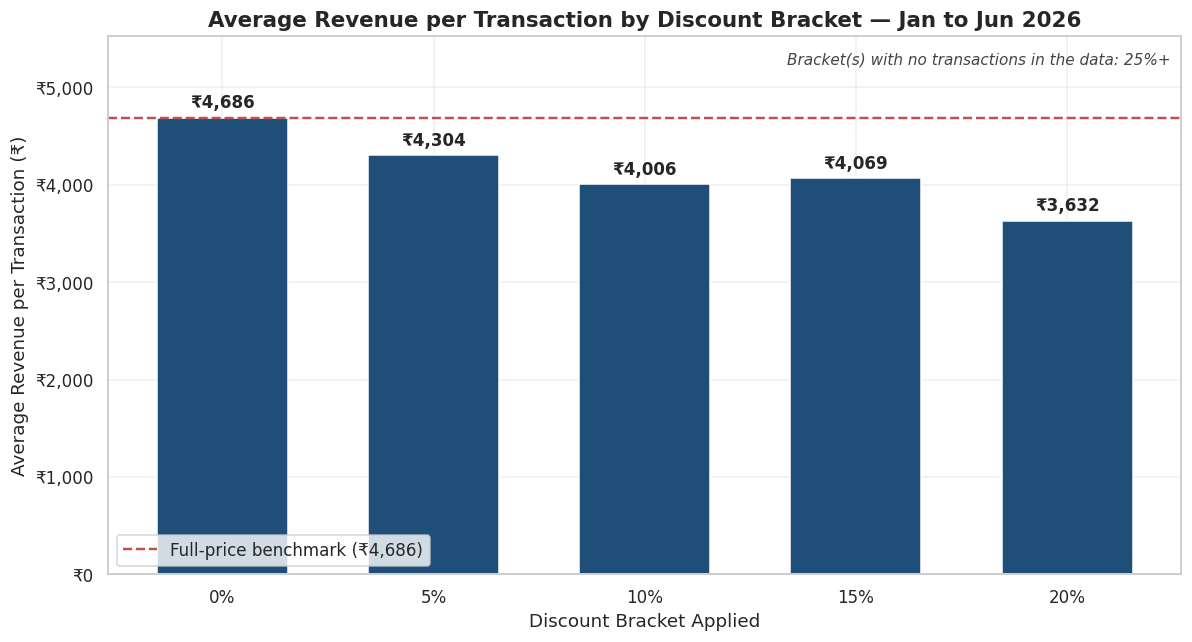

In [20]:
plot_data = discount_summary[discount_summary["transactions"] > 0]
empty_brackets = discount_summary.index[discount_summary["transactions"] == 0].tolist()

fig, ax = plt.subplots()
bars = ax.bar(plot_data.index.astype(str), plot_data["avg_revenue_per_transaction"],
              color=ACCENT, edgecolor="white", width=0.62)

for b, v in zip(bars, plot_data["avg_revenue_per_transaction"]):
    ax.text(b.get_x() + b.get_width()/2, v + 60, f"\u20b9{v:,.0f}",
            ha="center", va="bottom", fontsize=11, fontweight="bold")

baseline = plot_data["avg_revenue_per_transaction"].iloc[0]
ax.axhline(baseline, color="#c0504d", linestyle="--", linewidth=1.6,
           label=f"Full-price benchmark (\u20b9{baseline:,.0f})")

ax.set_title("Average Revenue per Transaction by Discount Bracket — Jan to Jun 2026")
ax.set_xlabel("Discount Bracket Applied")
ax.set_ylabel("Average Revenue per Transaction (\u20b9)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"\u20b9{v:,.0f}"))
ax.set_ylim(0, plot_data["avg_revenue_per_transaction"].max() * 1.18)
ax.legend(loc="lower left", frameon=True)

if empty_brackets:
    ax.text(0.99, 0.97, "Bracket(s) with no transactions in the data: " + ", ".join(empty_brackets),
            transform=ax.transAxes, ha="right", va="top", fontsize=10, style="italic", color="#444444")

plt.tight_layout()
plt.show()

In [21]:
# --- Is the fall in revenue per transaction just a category-mix effect? Control for it. ---
print("AVERAGE UNITS SOLD PER TRANSACTION, BY DISCOUNT BRACKET AND CATEGORY")
print(df.pivot_table(index="discount_bracket", columns="category",
                     values="units_sold", aggfunc="mean", observed=False).round(3).to_string())

print("\nAVERAGE REVENUE PER TRANSACTION (\u20b9), BY DISCOUNT BRACKET AND CATEGORY")
print(df.pivot_table(index="discount_bracket", columns="category",
                     values="revenue", aggfunc="mean", observed=False).round(0).to_string())

# Basket value BEFORE discount = units_sold x unit_price. If discounts pulled in bigger baskets,
# this pre-discount figure would rise with the bracket. It does not.
df["gross_basket_value"] = df["units_sold"] * df["unit_price"]
gross = df.groupby("discount_bracket", observed=False)["gross_basket_value"].mean()
print("\nAVERAGE PRE-DISCOUNT BASKET VALUE (\u20b9) BY BRACKET - tests whether discounts attract bigger baskets")
print(gross.round(2).to_string())

disc_txns = int((df["discount_pct"] > 0).sum())
print(f"\nDiscounted transactions: {disc_txns:,} of {len(df):,} ({disc_txns/len(df)*100:.1f}% of all transactions)")
print("Revenue foregone vs full list price (units x unit_price - revenue):",
      inr(df["gross_basket_value"].sum() - df["revenue"].sum()))

AVERAGE UNITS SOLD PER TRANSACTION, BY DISCOUNT BRACKET AND CATEGORY
category          Apparel  Electronics  Grocery  Home & Kitchen  Personal Care
discount_bracket                                                              
0%                  2.594        2.567    2.591           2.577          2.576
5%                  2.594        2.579    2.604           2.592          2.567
10%                 2.524        2.563    2.575           2.546          2.580
15%                 2.607        2.638    2.597           2.610          2.573
20%                 2.580        2.627    2.579           2.622          2.569

AVERAGE REVENUE PER TRANSACTION (₹), BY DISCOUNT BRACKET AND CATEGORY
category          Apparel  Electronics  Grocery  Home & Kitchen  Personal Care
discount_bracket                                                              
0%                 4918.0      61151.0    844.0         10635.0         1645.0
5%                 4633.0      57388.0    801.0          9851.0       

### Our position: the discount programme is not working — [Bandi Ashok]

**What happened.** Average revenue per transaction falls **monotonically as the discount rises**:
**₹4,685.65 at 0%**, ₹4,303.73 at 5%, ₹4,005.55 at 10%, ₹4,069.16 at 15% and **₹3,631.73 at 20%** —
**22.5% lower at the deepest discount than at full price**. Meanwhile average units sold is
**effectively flat across every bracket: 2.59, 2.59, 2.57, 2.60, 2.58**, a total spread of 0.03 units.
The **25%+ bracket contains zero transactions** — the maximum discount in this dataset is 20% — so
nothing is reported for it.

**And it is not a category-mix illusion.** Controlling for category, average units per transaction is
flat inside *every* category (Grocery 2.59 at 0% vs 2.58 at 20%; Electronics 2.57 vs 2.63; Apparel
2.59 vs 2.58), while revenue per transaction falls within every category as the discount deepens
(Home & Kitchen ₹10,635 → ₹8,608; Personal Care ₹1,645 → ₹1,302). The sharpest test: **average
pre-discount basket value is flat across brackets** (₹4,685 at 0%, ₹4,530 at 5%, ₹4,451 at 10%,
₹4,787 at 15%, ₹4,540 at 20%). If discounts were pulling in larger baskets, that number would climb
with the bracket. It does not.

**Our position, stated plainly.** Discounts in this dataset are **not generating incremental volume**.
They are changing the realised price on baskets the chain appears to have been selling anyway.
**66.6% of transactions (71,803 of 107,836) carry a discount**, and the gap between list value and
realised revenue across the period is **₹3.56 Cr**.

**The limitation, stated just as plainly.** This dataset contains `revenue` *after* discount and
carries **no cost, COGS or margin column**. We therefore **cannot and do not claim a measured margin
impact**. What we can say from the available evidence — revenue per transaction, units per
transaction, transaction counts and pre-discount basket value — is that the volume response the
discount is supposed to buy does not appear in the data. Whether the ₹3.56 Cr of foregone list value
translates into a proportionate margin loss can only be confirmed with cost data (see Step 6.6).

**What action this suggests.** Put the discount ladder itself on the supplier-review agenda: propose
a controlled test that withdraws 15% and 20% discounts in a subset of stores for one quarter and
measures the unit response, and redirect the funding toward the categories where the trend analysis
shows demand is already moving.

---

# Step 6.5 — Day-of-Week and Monthly Patterns

**Owner: [Member3Name] — Discount & Pattern Analyst**

Trend and product analysis tell the Category Manager *what* to promote. Timing analysis tells her
*when*.

In [22]:
DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["day_of_week"] = df["date"].dt.day_name()

daily_totals = df.groupby("date", as_index=False)["revenue"].sum()
daily_totals["day_of_week"] = daily_totals["date"].dt.day_name()

dow_chain = (daily_totals.groupby("day_of_week")["revenue"]
             .agg(avg_daily_revenue="mean", days_observed="count")
             .reindex(DAY_ORDER))
dow_chain["Index vs average day (100 = avg)"] = (
    dow_chain["avg_daily_revenue"] / dow_chain["avg_daily_revenue"].mean() * 100).round(1)

print("AVERAGE DAILY REVENUE BY DAY OF WEEK - WHOLE CHAIN")
dow_chain.round(2)

AVERAGE DAILY REVENUE BY DAY OF WEEK - WHOLE CHAIN


,avg_daily_revenue,days_observed,Index vs average day (100 = avg)
day_of_week,,,
Monday,2012140.96,26,79.3
Tuesday,2054129.70,26,80.9
Wednesday,2228117.24,25,87.8
Thursday,2245493.02,26,88.5
Friday,2623611.89,26,103.3
Saturday,3523605.44,26,138.8
Sunday,3083374.58,26,121.5


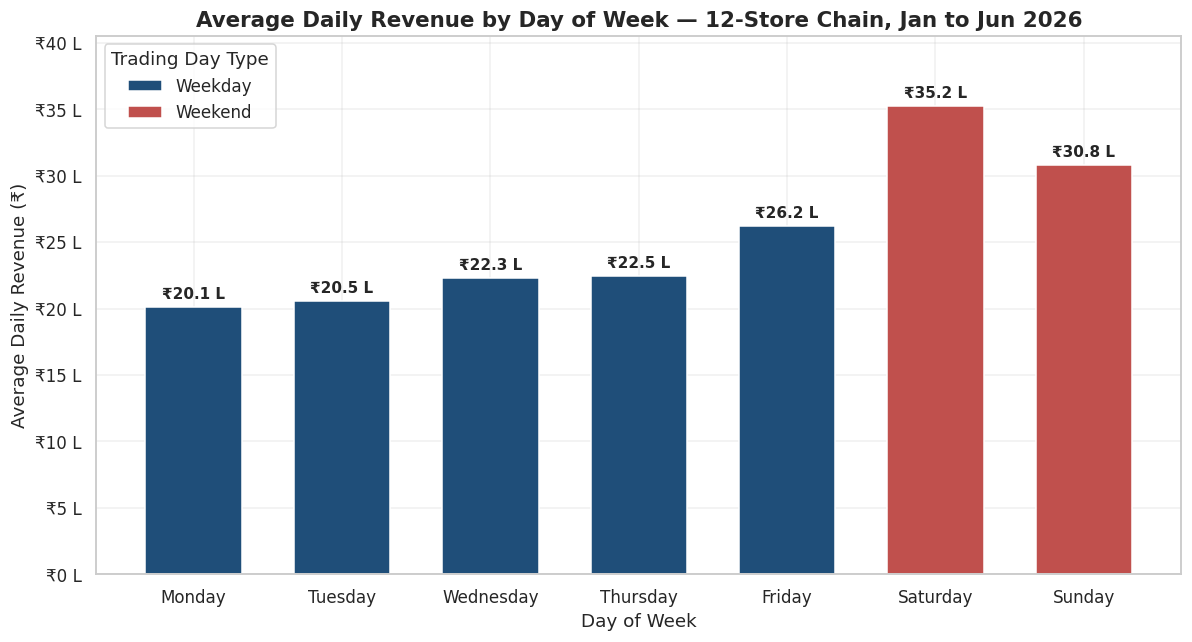

In [23]:
fig, ax = plt.subplots()
colors = [ACCENT if d not in ("Saturday", "Sunday") else "#c0504d" for d in DAY_ORDER]
bars = ax.bar(DAY_ORDER, dow_chain["avg_daily_revenue"], color=colors, edgecolor="white", width=0.65)
for b, v in zip(bars, dow_chain["avg_daily_revenue"]):
    ax.text(b.get_x() + b.get_width()/2, v + 40000, f"\u20b9{v/1e5:,.1f} L",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Average Daily Revenue by Day of Week — 12-Store Chain, Jan to Jun 2026")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Daily Revenue (\u20b9)")
rupee_axis(ax, scale=1e5, suffix=" L", decimals=0)
ax.set_ylim(0, dow_chain["avg_daily_revenue"].max() * 1.15)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=ACCENT, label="Weekday"),
                   Patch(facecolor="#c0504d", label="Weekend")],
          title="Trading Day Type", loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

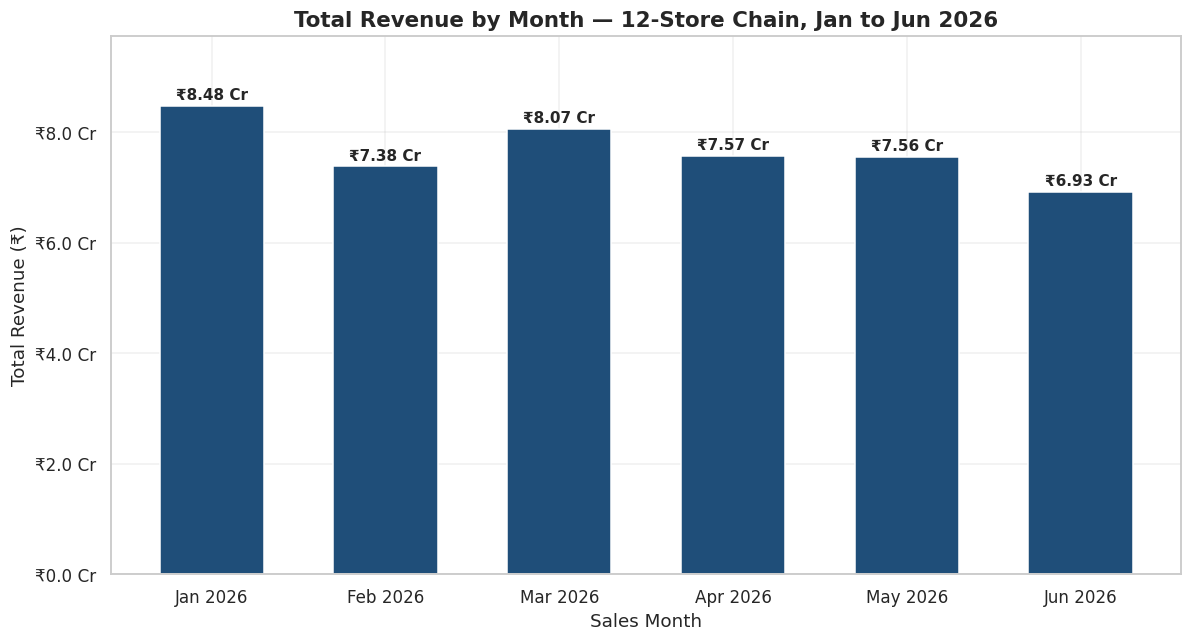

In [24]:
monthly_chain = df.groupby("month")["revenue"].sum()
monthly_chain.index = MONTH_ORDER

fig, ax = plt.subplots()
bars = ax.bar(monthly_chain.index, monthly_chain.values, color=ACCENT, edgecolor="white", width=0.6)
for b, v in zip(bars, monthly_chain.values):
    ax.text(b.get_x() + b.get_width()/2, v + 600000, f"\u20b9{v/1e7:,.2f} Cr",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Total Revenue by Month — 12-Store Chain, Jan to Jun 2026")
ax.set_xlabel("Sales Month")
ax.set_ylabel("Total Revenue (\u20b9)")
rupee_axis(ax, scale=1e7, suffix=" Cr", decimals=1)
ax.set_ylim(0, monthly_chain.max() * 1.15)
plt.tight_layout()
plt.show()

In [25]:
best_day, worst_day = dow_chain["avg_daily_revenue"].idxmax(), dow_chain["avg_daily_revenue"].idxmin()
best_month, worst_month = monthly_chain.idxmax(), monthly_chain.idxmin()

print("CHAIN-LEVEL PEAKS AND TROUGHS")
print(f"Best day    : {best_day:<10} {inr(dow_chain['avg_daily_revenue'].max())} average per day")
print(f"Worst day   : {worst_day:<10} {inr(dow_chain['avg_daily_revenue'].min())} average per day")
print(f"  Saturday earns {dow_chain['avg_daily_revenue'].max()/dow_chain['avg_daily_revenue'].min():.2f}x a Monday")
print(f"Best month  : {best_month:<10} {inr(monthly_chain.max())}")
print(f"Worst month : {worst_month:<10} {inr(monthly_chain.min())}")

weekend = daily_totals["day_of_week"].isin(["Saturday", "Sunday"])
print(f"\nWeekend average day : {inr(daily_totals.loc[weekend, 'revenue'].mean())}")
print(f"Weekday average day : {inr(daily_totals.loc[~weekend, 'revenue'].mean())}")
print(f"Weekend uplift      : {(daily_totals.loc[weekend,'revenue'].mean()/daily_totals.loc[~weekend,'revenue'].mean()-1)*100:.1f}%")

CHAIN-LEVEL PEAKS AND TROUGHS
Best day    : Saturday   ₹35.24 L average per day
Worst day   : Monday     ₹20.12 L average per day
  Saturday earns 1.75x a Monday
Best month  : Jan 2026   ₹8.48 Cr
Worst month : Jun 2026   ₹6.93 Cr

Weekend average day : ₹33.03 L
Weekday average day : ₹22.33 L
Weekend uplift      : 48.0%


In [26]:
# --- The single most interesting category from Step 6.2: Electronics ---
# Chosen because it is 49.3% of chain revenue AND the steepest decliner (-35.02%).
FOCUS = "Electronics"
focus_df = df[df["category"] == FOCUS]

focus_daily = focus_df.groupby("date", as_index=False)["revenue"].sum()
focus_daily["day_of_week"] = focus_daily["date"].dt.day_name()
focus_dow = focus_daily.groupby("day_of_week")["revenue"].mean().reindex(DAY_ORDER)

comparison = pd.DataFrame({
    "Chain index (100 = its average day)": (dow_chain["avg_daily_revenue"] / dow_chain["avg_daily_revenue"].mean() * 100).round(1),
    f"{FOCUS} index (100 = its average day)": (focus_dow / focus_dow.mean() * 100).round(1),
})
comparison["Gap (pts)"] = (comparison.iloc[:, 1] - comparison.iloc[:, 0]).round(1)

print(f"DAY-OF-WEEK SHAPE: WHOLE CHAIN vs {FOCUS.upper()} (indexed so the two are directly comparable)")
print(comparison.to_string())
print(f"\n{FOCUS} best day : {focus_dow.idxmax()} ({inr(focus_dow.max())} average per day)")
print(f"{FOCUS} worst day: {focus_dow.idxmin()} ({inr(focus_dow.min())} average per day)")

focus_monthly = focus_df.groupby("month")["revenue"].sum()
focus_monthly.index = MONTH_ORDER
print(f"\n{FOCUS} best month : {focus_monthly.idxmax()} ({inr(focus_monthly.max())})")
print(f"{FOCUS} worst month: {focus_monthly.idxmin()} ({inr(focus_monthly.min())})")

DAY-OF-WEEK SHAPE: WHOLE CHAIN vs ELECTRONICS (indexed so the two are directly comparable)
             Chain index (100 = its average day)  Electronics index (100 = its average day)  Gap (pts)
day_of_week                                                                                           
Monday                                      79.3                                       77.6       -1.7
Tuesday                                     80.9                                       78.0       -2.9
Wednesday                                   87.8                                       88.9        1.1
Thursday                                    88.5                                       84.9       -3.6
Friday                                     103.3                                      103.2       -0.1
Saturday                                   138.8                                      142.8        4.0
Sunday                                     121.5                                     

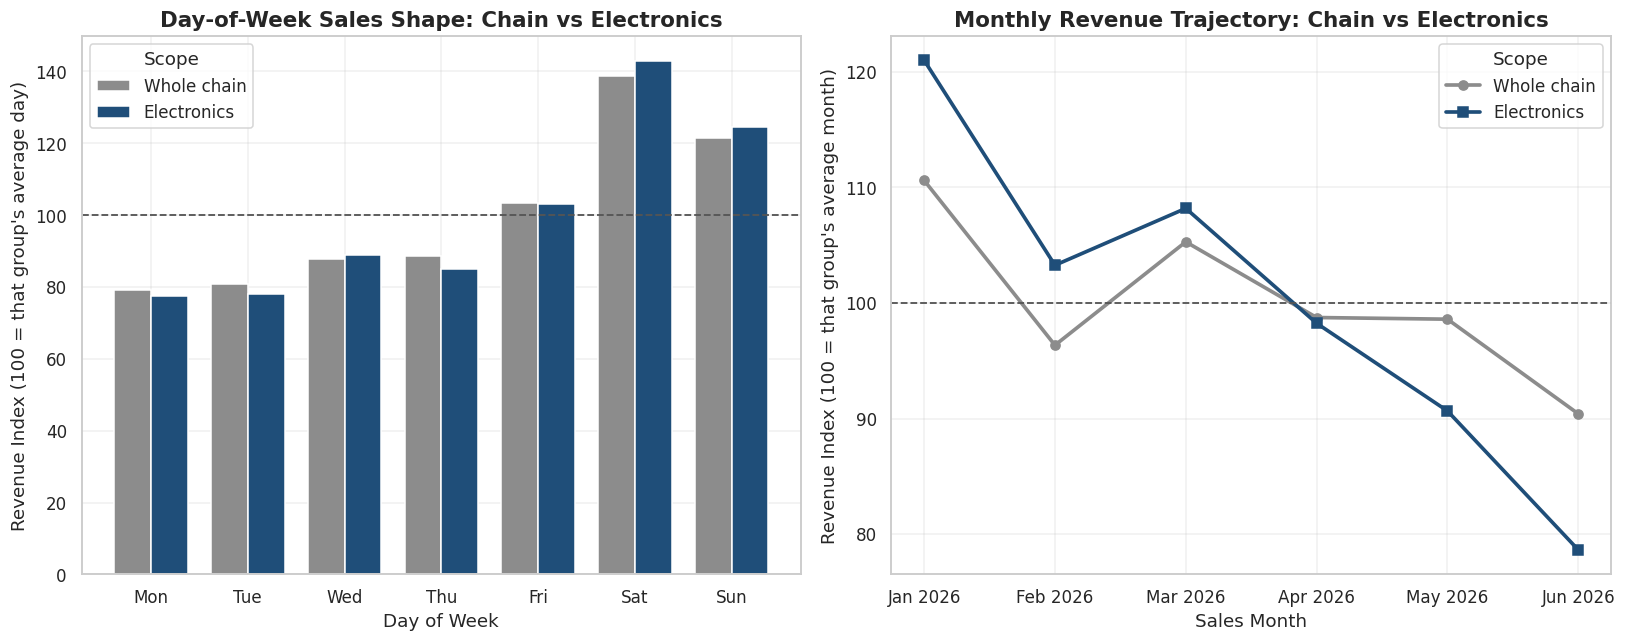

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

x = np.arange(len(DAY_ORDER)); w = 0.38
NEUTRAL = "#8c8c8c"   # whole chain drawn in neutral grey so the focus category stands out
ax1.bar(x - w/2, comparison["Chain index (100 = its average day)"], width=w,
        color=NEUTRAL, edgecolor="white", label="Whole chain")
ax1.bar(x + w/2, comparison[f"{FOCUS} index (100 = its average day)"], width=w,
        color=CATEGORY_COLOURS[FOCUS], edgecolor="white", label=FOCUS)
ax1.axhline(100, color="#555555", linestyle="--", linewidth=1.2)
ax1.set_title(f"Day-of-Week Sales Shape: Chain vs {FOCUS}")
ax1.set_xlabel("Day of Week")
ax1.set_ylabel("Revenue Index (100 = that group's average day)")
ax1.set_xticks(x); ax1.set_xticklabels([d[:3] for d in DAY_ORDER])
ax1.legend(title="Scope", frameon=True)

chain_idx = monthly_chain / monthly_chain.mean() * 100
focus_idx = focus_monthly / focus_monthly.mean() * 100
ax2.plot(MONTH_ORDER, chain_idx.values, marker="o", linewidth=2.4, color=NEUTRAL, label="Whole chain")
ax2.plot(MONTH_ORDER, focus_idx.values, marker="s", linewidth=2.4,
         color=CATEGORY_COLOURS[FOCUS], label=FOCUS)
ax2.axhline(100, color="#555555", linestyle="--", linewidth=1.2)
ax2.set_title(f"Monthly Revenue Trajectory: Chain vs {FOCUS}")
ax2.set_xlabel("Sales Month")
ax2.set_ylabel("Revenue Index (100 = that group's average month)")
ax2.legend(title="Scope", frameon=True)

plt.tight_layout()
plt.show()

### What the timing analysis means — [Bandi Ashok]

**What happened — chain level.** Revenue is heavily weekend-loaded. **Saturday is the best day at an
average ₹35.24 L, Monday the worst at ₹20.12 L** — Saturday earns **1.75× a Monday**, and the average
weekend day runs **48.0% ahead of the average weekday**. By month, **January was the best at ₹8.48 Cr
and June the worst at ₹6.93 Cr**, an 18.3% decline across the half-year with no recovery month.

**The most interesting category is Electronics** — it is 49.3% of chain revenue and the steepest
decliner (−35.02%), so it drives both patterns.

**Does it follow the chain?** On day of week, **it follows the chain's shape but amplifies it**.
Indexed against its own average day, Electronics reads Saturday **142.8** vs the chain's 138.8 and
Monday **77.6** vs the chain's 79.3 — the same weekend peak and Monday trough, only steeper. Its best
and worst days are identical to the chain's (Saturday ₹17.87 L, Monday ₹9.71 L). **On the monthly
trajectory it behaves very differently**: the chain falls 18.3% Jan→Jun while Electronics falls
35.02%, so Electronics is not riding a general chain slowdown — it is causing most of it, and the two
lines diverge steadily from March onward.

**What this means for promotional timing.** Promotional weight should be concentrated where demand
already exists — Friday through Sunday, and in Electronics especially, where the weekend skew is
sharpest — rather than spent trying to manufacture a Monday or Tuesday that has never performed.
Because Step 6.4 shows discounts move price rather than units, the more defensible lever for the weak
Monday–Thursday window is non-price activity (availability, staffing, in-store demonstration) rather
than deeper markdowns. And because Electronics' monthly decline runs at roughly twice the chain's,
its promotional calendar should be rebuilt around a recovery plan with a measurable June-exit run
rate rather than around seasonal peaks the category is no longer reaching.

---

# Category Manager Briefing

**Owner: [Vikas] — Business Synthesis Analyst**

**Back Apparel with incremental shelf space and promotional funding**: it is the only category growing
consistently, up **34.10% from ₹1.00 Cr in January to ₹1.35 Cr in June (+₹34.27 L)**, rising in every
month but February, while the chain overall fell 18.3% — it is winning share against the trend, not
riding it. **Challenge the Electronics category in the meeting**: it is ₹22.65 Cr and 49.3% of chain
revenue, yet it fell **35.02%, from ₹4.57 Cr in January to ₹2.97 Cr in June — a loss of ₹1.60 Cr,
larger than the chain's entire ₹1.55 Cr decline** — and all five of its products are down, led by
**Mobile Phone at −57.1% (₹98.03 L → ₹42.10 L)** and **Smart TV, the category's weakest product at
₹4.19 Cr**; the driver is footfall, not price, with transactions down from 790 to 526 a month while
average unit price held near ₹23,600, so the supplier owes us an explanation and a recovery plan
before any further promotional investment is committed. **On discounts, raise this with every
supplier**: average revenue per transaction falls steadily from **₹4,685.65 at full price to
₹3,631.73 at 20% off (−22.5%)** while average units sold stays flat at **2.57–2.60 across every
bracket and every category** — the ₹3.56 Cr gap between list value and realised revenue is buying no
measurable extra volume, so the discount ladder should be tested down, starting with a controlled
withdrawal of the 15% and 20% brackets in a subset of stores. **Time promotional weight to Friday–Sunday**,
where the chain earns 48.0% more per day than midweek and Electronics skews harder still (Saturday
index 142.8 vs Monday 77.6). **Before the final shelf-space decision I want one more dataset:
product-level cost or margin data.** This file contains revenue after discount but no cost column, so
we can evidence that discounts are not driving volume but we cannot yet quantify the margin
destroyed — and Electronics' scale means a shelf-space call made on revenue alone could easily favour
the category that contributes the least profit per rupee of space.

---

### Analysis limitations

- **No cost or margin data.** `revenue` is post-discount; there is no COGS column, so margin impact is
  inferred from revenue and volume behaviour, never measured.
- **No supplier identifiers.** The dataset has no supplier column, so all challenges are framed at
  category and product level rather than against named suppliers.
- **Six months only, with no prior-year comparison.** We cannot separate the Electronics decline from
  seasonality; a same-period 2025 extract would settle that.
- **The brief describes discounts up to 30%; the file contains a maximum of 20%.** The 25%+ bracket is
  reported as empty rather than estimated.

---

*Prepared by [Team_12] · [Geetha] (Data Analyst) · [Mulla Javeed] (Product Insights Analyst) · [Ashok] (Discount & Pattern Analyst) · [vikas] (Business Synthesis Analyst)*
*All figures calculated from `MUC01_Retail_Sales_Dataset.csv`, 107,836 transactions, 1 Jan – 30 Jun 2026.*